In [1]:
using PlotlyJS
using Infiltrator
using XLSX
using CSV
include("./processing.jl")
include("../model/utils/empirical_mu.jl")


solve_empirical_μ_get_solution (generic function with 1 method)

In [2]:
day = 7
input_folder = "../input/RTS-GMLC_v1.0"
ε = 0.025
ρ = 0.8
gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
;

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...


Checking that max_{i in T} ER[s,i,t]<=sum(R[S,τ], τ<=t) 

In [3]:
max_required_energy_reserve = combine(groupby(required_energy_reserve, [:t_hour]),[:reserve_up_MW, :reserve_down_MW].=> maximum, renamecols = false)
rename!(max_required_energy_reserve,:t_hour => :hour)
cumsum_required_reserve = combine(required_reserve, [:reserve_up_MW, :reserve_down_MW] .=> cumsum, renamecols = false)
# cumsum_required_reserve.hour .= required_reserve.hour
# cumsum_required_reserve = required_reserve[:, [:hour, :reserve_up_MW, :reserve_down_MW]] .|> cumsum 
delta_reserve = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- max_required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta_reserve.hour .= required_reserve.hour
all.(delta_reserve[:,[:reserve_up_MW, :reserve_down_MW]] .>=0)


Row,reserve_up_MW,reserve_down_MW
,Bool,Bool
1,true,true
2,true,true
3,true,true
4,true,true
5,true,true
6,true,true
7,true,true
8,true,true
9,true,true


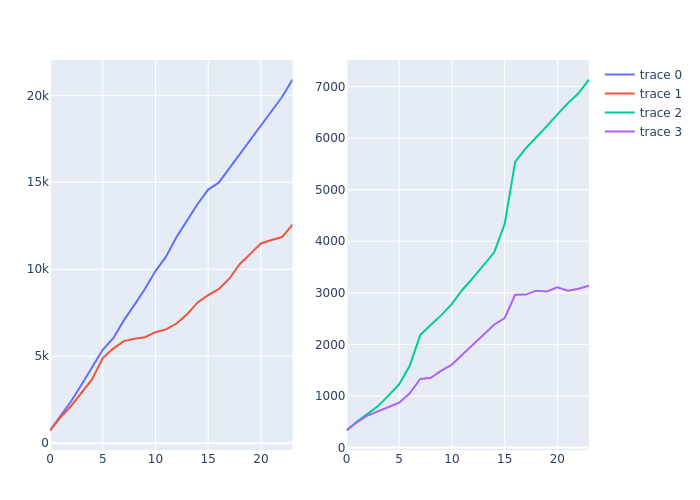

In [4]:
s1 = scatter(cumsum_required_reserve, y = :reserve_up_MW)
s2 = scatter(max_required_energy_reserve, y = :reserve_up_MW)
p1 = plot([s1;s2])

s1 = scatter(cumsum_required_reserve, y = :reserve_down_MW)
s2 = scatter(max_required_energy_reserve, y = :reserve_down_MW)
p2 = plot([s1;s2])
[p1 p2]

# plot(stack(delta_reserve, [:reserve_up_MW, :reserve_down_MW]), x = :hour, y = :value, group = :variable)

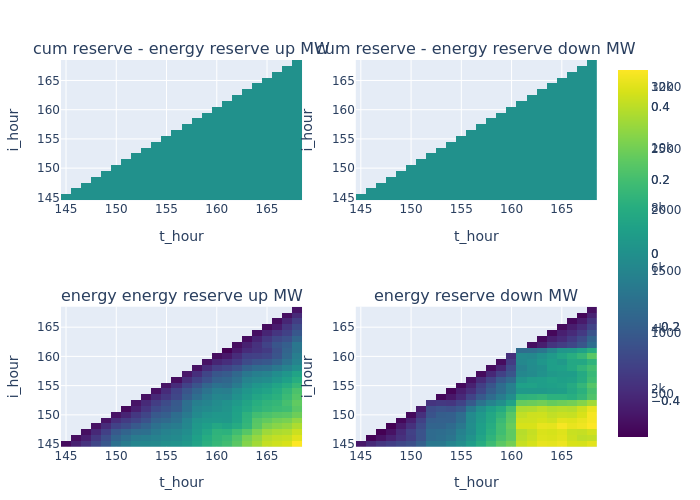

In [5]:
cumsum_required_reserve = required_energy_reserve[:,[:i_hour,:t_hour]] # cumualtive required reserve between i and t
f(i,t,df) = 
    (reserve_up_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_up_MW]),
    reserve_down_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_down_MW]),
    )
transform!(groupby(cumsum_required_reserve,[:i_hour, :t_hour]), [:i_hour, :t_hour] => ((i,t) -> f(i,t,required_reserve)) => AsTable)
;
# delta with energy reserve. 
delta = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta.i_hour .= cumsum_required_reserve.i_hour
delta.t_hour .= cumsum_required_reserve.t_hour
delta[delta.reserve_up_MW .>=0,:reserve_up_MW].= 0
delta[delta.reserve_down_MW .>=0,:reserve_down_MW].= 0
# delta = filter(row -> all(x -> x <= 0, row[[:reserve_up_MW, :reserve_down_MW]]), delta)
;
p1 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_up_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p2 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_down_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p3 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_up_MW, colorscale="Viridis"), Layout(title="energy energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p4 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_down_MW, colorscale="Viridis"), Layout(title="energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
# p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNDIS, colorscale="Viridis"))
# p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNCH, colorscale="Viridis"))
[p1 p2; p3 p4]

In [6]:
temportal_weights = false
model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve; temportal_weights = temportal_weights)
# sol_1 = dropmissing(sol_1)
;


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
MIPGap  1e-06

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 2932 columns and 18176 nonzeros
Model fingerprint: 0xe4dda0b8
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 1e+04]
Presolve removed 1944 rows a

In [12]:
sol_1

Row,r_id,t,RESUP,RESDN,RESUPDIS,RESUPCH,RESDNCH,RESDNDIS,SOEUP,SOEDN,MAXERESUPDIS,MAXERESUPCH,MAXERESDNCH,MAXERESDNDIS,εUPDIS,εUPCH,εDNCH,εDNDIS,θUPDIS,θUPCH,θDNCH,θDNDIS
,Int64,Int64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,101,145,733.898,330.14,357.518,376.379,165.462,164.678,0.0,0.0,357.518,376.379,165.462,164.678,0.0,0.0,0.0,0.0,357.518,376.379,165.462,164.678
2,101,146,822.181,172.546,402.429,419.752,81.9678,90.5777,0.0,0.0,751.885,788.029,245.264,253.218,0.0,0.0,0.0,0.0,394.366,411.649,79.8018,88.5399
3,101,147,858.758,150.672,418.819,439.939,71.4362,79.2363,0.0,0.0,1158.96,1215.95,313.058,328.804,0.0,0.0,0.0,0.0,407.078,427.922,67.7941,75.5857
4,101,148,961.889,150.08,474.451,487.437,70.8717,79.208,0.0,0.0,1619.77,1689.35,378.684,402.52,0.0,0.0,0.0,0.0,460.802,473.394,65.6258,73.7169
5,101,149,981.582,207.212,484.803,496.778,100.923,106.289,0.0,0.0,2088.84,2169.95,473.023,501.798,0.000185414,0.000184863,0.000180231,0.000182342,469.075,480.603,94.3397,99.2773
6,101,150,1012.16,215.234,505.626,506.537,102.488,112.746,0.0,0.0,2576.38,2657.97,567.387,605.94,0.000185165,0.000184517,0.000179689,0.000181971,487.543,488.022,94.3634,104.142
7,101,151,665.815,359.735,313.334,352.481,178.168,181.567,0.0,0.0,2868.05,2988.12,734.799,776.47,0.00018509,0.000184437,0.000179766,0.000182016,291.666,330.145,167.412,170.53
8,101,152,1025.97,597.311,516.22,509.748,313.032,284.28,0.0,0.0,3355.86,3468.79,1033.13,1046.87,0.000185379,0.000184906,0.000181373,0.000183022,487.814,480.68,298.336,270.398
9,101,153,890.216,199.069,436.496,453.72,93.0291,106.04,0.0,0.0,3758.17,3887.32,1112.26,1139.36,0.000185399,0.000184992,0.000181935,0.000183476,402.304,418.527,79.1249,92.4893


In [13]:
println(value(model[:epsilon_variance]))
println(value(model[:theta]))
println(value(model[:reserve]))
# println(value(model[:slack]))
println(objective_value(model))

2.5685955324038125e-6
15703.710604446895
28043.703931537
-12339.99332452151


In [14]:
function calculate_mu_t(sol_1_)
    sol_1 = dropmissing(sol_1_)
    mu = DataFrame()
    for (θ, RES) in [(:θUPDIS, :RESUPDIS), (:θUPCH, :RESUPCH), (:θDNDIS, :RESDNDIS), (:θDNCH, :RESDNCH)]
        # mu[!, Symbol("$θ/$RES")] = cumsum(sol_1[:, θ]) ./ cumsum(sol_1[:, RES]) # comment this to get cumulative ratio
        mu[!, Symbol("$θ/$RES")] = (sol_1[:, θ]) ./ (sol_1[:, RES])
    end
    mu[!, :t] = sol_1.t
    mu = mu[1:end, :]
    leftjoin!(sol_1, mu, on = :t)
    
    return unstack(stack(mu, Not(:t), variable_name=:mu),:t, :value)
end
mu_t = calculate_mu_t(sol_1)
# mu_t


Row,mu,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,θUPDIS/RESUPDIS,1.0,0.979965,0.971966,0.971232,0.967558,0.964237,0.930849,0.944974,0.921667,0.90713,0.900258,0.831955,0.807094,0.625513,0.293816,0.292717,0.291987,0.115917,0.0801193,0.0633473,0.0587266,0.0545183,0.0352263,0.027566
2,θUPCH/RESUPCH,1.0,0.980697,0.972686,0.97119,0.967439,0.963448,0.936632,0.942974,0.922434,0.907912,0.898639,0.837323,0.798452,0.604568,0.288883,0.291197,0.275465,0.114671,0.0766085,0.0571165,0.0525773,0.0588132,0.0305775,0.0240344
3,θDNDIS/RESDNDIS,1.0,0.977502,0.953928,0.930675,0.934031,0.923689,0.939214,0.951167,0.87221,0.824121,0.802655,0.760122,0.532176,0.232635,0.173328,0.0677517,0.0330205,0.0445006,0.0293068,0.0240707,0.0179106,0.011691,0.011211,0.00676068
4,θDNCH/RESDNCH,1.0,0.973574,0.949016,0.925981,0.934769,0.920729,0.939628,0.953054,0.85054,0.821224,0.800458,0.760395,0.52759,0.253943,0.194373,0.140646,0.0214322,0.0463033,0.0328026,0.0261836,0.0189214,0.01259,0.0130208,0.00823862


┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ DataFramesExt /home/pabloncho/.julia/packages/PlotlyBase/YrV0o/ext/DataFramesExt.jl:257
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ DataFramesExt /home/pabloncho/.julia/packages/PlotlyBase/YrV0o/ext/DataFramesExt.jl:257
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ DataFramesExt /home/pabloncho/.julia/packages/PlotlyBase/YrV0o/ext/DataFramesExt.jl:257


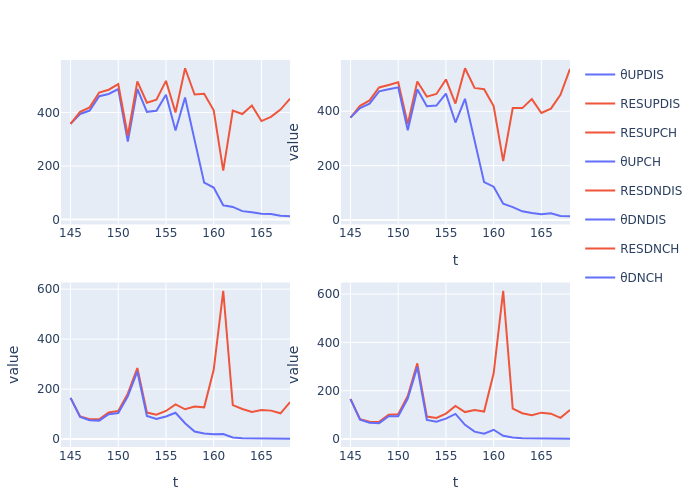

In [15]:
ks = [:θUPDIS,:RESUPDIS]
s1 = scatter(stack(sol_1, ks), x = :t, y = :value, color=:r_id, group =:variable, facet_col = :r_id)
p1 = plot(s1)
# ks = ["θUPDIS/RESUPDIS"]
# s2 = scatter(stack(sol_1, ks),  x = :t, y = :value, color=:r_id, group =:variable, yaxis="y2")
# p1 = plot([s1; s2], Layout(yaxis2 = attr(overlaying="y", side="right")))

ks = [:θUPCH,:RESUPCH]
p2 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

ks = [:θDNDIS,:RESDNDIS]
p3 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

ks = [:θDNCH,:RESDNCH]
p4 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

[p1 p2; p3 p4]

┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ DataFramesExt /home/pabloncho/.julia/packages/PlotlyBase/YrV0o/ext/DataFramesExt.jl:257
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ DataFramesExt /home/pabloncho/.julia/packages/PlotlyBase/YrV0o/ext/DataFramesExt.jl:257
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ DataFramesExt /home/pabloncho/.julia/packages/PlotlyBase/YrV0o/ext/DataFramesExt.jl:257
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ DataFramesExt /home/pabloncho/.julia/packages/PlotlyBase/YrV0o/ext/DataFramesExt.jl:257


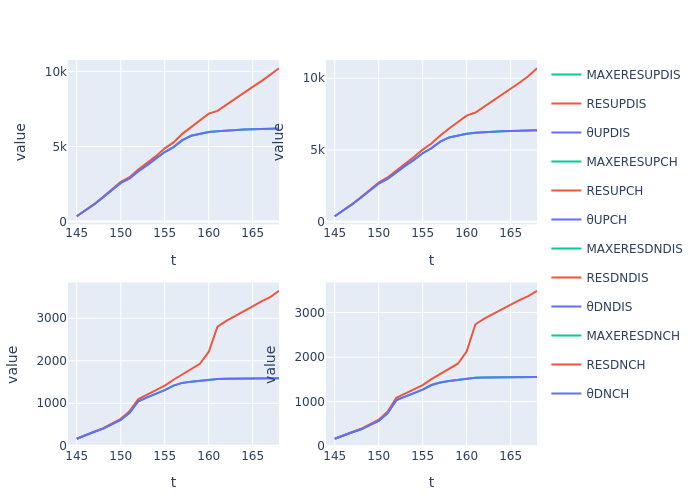

In [16]:
cumsum_sol_1 = combine(groupby(sol_1, :r_id), [:RESUPDIS, :RESDNDIS, :RESUPCH, :RESDNCH, :θUPDIS, :θUPCH, :θDNCH, :θDNDIS] .=> cumsum, renamecols = false)
cumsum_sol_1.t = unique(sol_1.t)
leftjoin!(cumsum_sol_1, sol_1[:, [:r_id, :t, :MAXERESUPDIS, :MAXERESUPCH, :MAXERESDNCH, :MAXERESDNDIS]], on = [:r_id, :t])

ks = [:θUPDIS,:RESUPDIS,:MAXERESUPDIS]
p1 = plot(stack(cumsum_sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θUPCH,:RESUPCH, :MAXERESUPCH]
p2 = plot(stack(cumsum_sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNDIS,:RESDNDIS, :MAXERESDNDIS]
p3 = plot(stack(cumsum_sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNCH,:RESDNCH, :MAXERESDNCH]
p4 = plot(stack(cumsum_sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

[p1 p2; p3 p4]

In [12]:
p1 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPDIS, colorscale="Viridis"), Layout(title="ERESUPDIS"))
p2 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPCH, colorscale="Viridis"), Layout(title="ERESUPCH"))
p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNDIS, colorscale="Viridis"), Layout(title="ERESDNDIS"))
p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNCH, colorscale="Viridis"), Layout(title="ERESDNCH"))
[p1 p2; p3 p4]

data: [
  "heatmap with fields colorscale, transpose, type, x, xaxis, y, yaxis, and z",
  "heatmap with fields colorscale, transpose, type, x, xaxis, y, yaxis, and z",
  "heatmap with fields colorscale, transpose, type, x, xaxis, y, yaxis, and z",
  "heatmap with fields colorscale, transpose, type, x, xaxis, y, yaxis, and z"
]

layout: "layout with fields annotations, margin, template, xaxis1, xaxis2, xaxis3, xaxis4, yaxis1, yaxis2, yaxis3, and yaxis4"

In [ ]:
# rhos = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.99]
days = [1,2]
temportal_weights = false
mu_t_all = DataFrame()
for day in days
    input_folder = "../input/RTS-GMLC_v1.0"
    gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder)
    required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df)
    model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve; temportal_weights = temportal_weights)
    mu_t = calculate_mu_t(sol_1)
    # mu_t = insertcols(mu_t, 1, :rho => rho)
    mu_t = insertcols(mu_t, 1, :day => day)
    append!(mu_t_all, mu_t)
end
CSV.write("empirical_mu.csv", mu_t_all)
# transform!(mu_t_all, AsTable(Not([:rho, :variable])) => ByRow(x -> mean(x)) => :mean)

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
MIPGap  1e-06

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 2932 columns and 18176 nonzeros
Model fingerprint: 0xd30ea8bb
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds 

"empirical_mu.csv"